# 🏥 Insurance Cost Prediction using Linear Regression

**Project by:** Poluri Sai Niyathi | B.Tech CSE, 2nd Year  
**Dataset:** Medical Insurance dataset (with missing values — real-world messiness included!)

---

### 📌 What This Project Does
This notebook builds a Machine Learning model to **predict a person's medical insurance charges** based on factors like age, BMI, smoking status, and region.

I tried three regression models — Linear Regression, Lasso, and Ridge — and compared their performance.

### 📦 Steps Covered
1. Load and explore the data
2. Handle missing values
3. Encode categorical columns
4. Train/test split + feature scaling
5. Train models and compare
6. Visualize results

## Step 1 — Import Libraries

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Step 2 — Load & Explore the Dataset



In [28]:
df = pd.read_csv("insurance.csv")

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19.0,female,27.900,0.0,yes,southwest,16884.92400
1,18.0,male,NaN,1.0,no,southeast,1725.55230
2,28.0,male,33.000,3.0,no,southeast,NaN
3,33.0,male,22.705,0.0,no,northwest,21984.47061
4,32.0,male,28.880,0.0,NaN,northwest,3866.85520


In [29]:
# Quick look at data types and missing value count
print("Data types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

Data types:
age         float64
sex          object
bmi         float64
children    float64
smoker       object
region       object
charges     float64
dtype: object

Missing values per column:
age         67
sex         67
bmi         67
children    67
smoker      67
region      67
charges     67
dtype: int64


## Step 3 — Split Features and Target

In [30]:
# 'charges' is what we want to predict → this is our y (target)
# everything else goes into X (features)
X = df.drop("charges", axis=1)
y = df["charges"]

print("Features (X):")
print(X.head(3))
print("\nTarget (y):")
print(y.head(3))

Features (X):
    age     sex   bmi  children smoker     region
0  19.0  female  27.9       0.0    yes  southwest
1  18.0    male   NaN       1.0     no  southeast
2  28.0    male  33.0       3.0     no  southeast

Target (y):
0    16884.9240
1     1725.5523
2           NaN
Name: charges, dtype: float64


## Step 4 — Handle Missing Values

**Strategy used:**
- **Numerical columns** (age, bmi, children, charges) → fill with **median** (median is better than mean when there are outliers)
- **Categorical columns** (sex, smoker, region) → fill with **mode** (most common value)

In [31]:
# Fill numerical missing values with median
y = y.fillna(y.median())
X['age']      = X['age'].fillna(X['age'].median())
X['bmi']      = X['bmi'].fillna(X['bmi'].median())
X['children'] = X['children'].fillna(X['children'].median())

# Fill categorical missing values with mode
X['sex']    = X['sex'].fillna(X['sex'].mode()[0])
X['smoker'] = X['smoker'].fillna(X['smoker'].mode()[0])
X['region'] = X['region'].fillna(X['region'].mode()[0])

# Confirm no missing values remain
print("Missing values after cleaning:")
print(X.isnull().sum())
print("Target missing values:", y.isnull().sum())

Missing values after cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64
Target missing values: 0


## Step 5 — Encode Categorical Variables

ML models need numbers, not text. We use **One-Hot Encoding** to convert categorical columns into 0s and 1s.

`drop_first=True` removes one dummy column per category to avoid the dummy variable trap.

In [32]:
X = pd.get_dummies(X, drop_first=True)

print("Columns after encoding:", list(X.columns))
X.head()

Columns after encoding: ['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19.0,27.900,0.0,False,True,False,False,True
1,18.0,30.210,1.0,True,False,False,True,False
2,28.0,33.000,3.0,True,False,False,True,False
3,33.0,22.705,0.0,True,False,True,False,False
4,32.0,28.880,0.0,True,False,True,False,False


## Step 6 — Train/Test Split & Feature Scaling

- **80% training**, **20% testing** — standard split
- **StandardScaler** brings all features to the same scale so no single feature dominates

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

print("\nScaling done.")

Training samples : 1070
Testing samples  : 268

Scaling done.


## Step 7 — Train Models & Compare

I tried three regression models:
| Model | What's different? |
|---|---|
| Linear Regression | Basic — minimizes error directly |
| Lasso (L1) | Adds penalty → can zero out unimportant features |
| Ridge (L2) | Adds penalty → shrinks coefficients, good for correlated features |

In [34]:
results = {}

# --- Linear Regression ---
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results['Linear Regression'] = {
    'R2'  : r2_score(y_test, y_pred_lr),
    'MAE' : mean_absolute_error(y_test, y_pred_lr),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr))
}

# --- Lasso ---
lasso = Lasso(alpha=0.0001)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

results['Lasso'] = {
    'R2'  : r2_score(y_test, y_pred_lasso),
    'MAE' : mean_absolute_error(y_test, y_pred_lasso),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lasso))
}

# --- Ridge ---
ridge = Ridge(alpha=0.001)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

results['Ridge'] = {
    'R2'  : r2_score(y_test, y_pred_ridge),
    'MAE' : mean_absolute_error(y_test, y_pred_ridge),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ridge))
}

# Display comparison table
results_df = pd.DataFrame(results).T.round(2)
print("Model Comparison:")
results_df

Model Comparison:


,R2,MAE,RMSE
Linear Regression,0.71,4746.7,6599.74
Lasso,0.71,4746.7,6599.74
Ridge,0.71,4746.7,6599.74


## Step 8 — Feature Importance (Ridge Coefficients)

Which features matter most for predicting insurance charges?

In [35]:
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

         Feature  Coefficient
      smoker_yes  8861.261435
             age  3369.589193
             bmi  1753.565502
        children   583.183283
        sex_male  -165.399621
region_northwest  -243.683806
region_southeast  -332.299483
region_southwest  -361.474946


## Step 9 — Visualizations

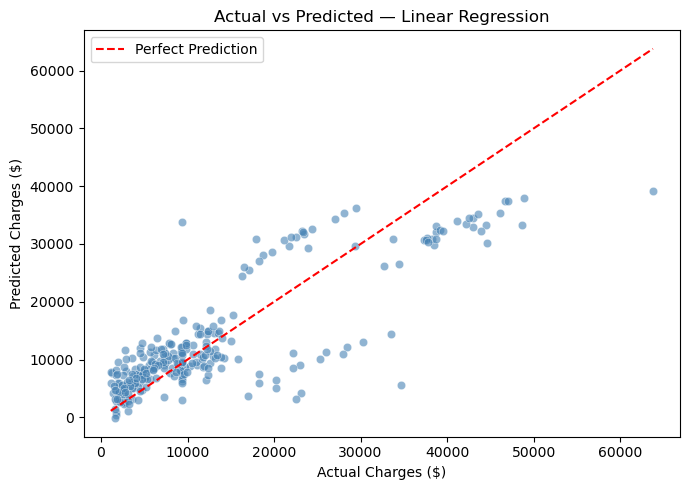

Points closer to the red line = better predictions!


In [36]:
# --- Plot 1: Actual vs Predicted (Linear Regression) ---
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect Prediction')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title("Actual vs Predicted — Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

print("Points closer to the red line = better predictions!")

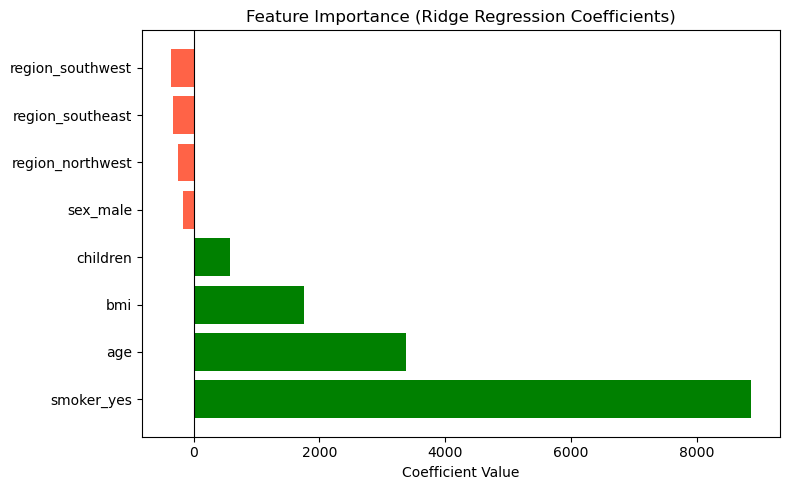

Green = increases predicted charge | Red = decreases predicted charge


In [37]:
# --- Plot 2: Feature Importance Bar Chart ---
plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'tomato' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Ridge Regression Coefficients)")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("Green = increases predicted charge | Red = decreases predicted charge")

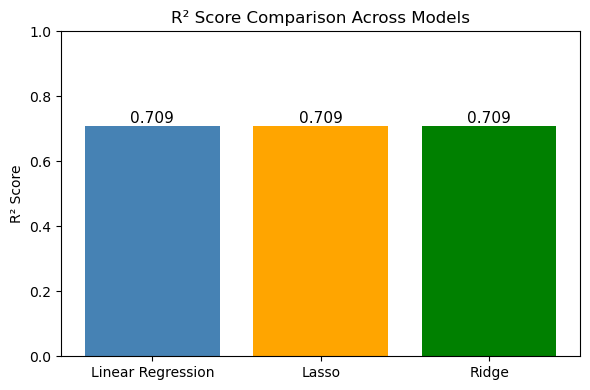

In [38]:
# --- Plot 3: Model R² Comparison Bar Chart ---
model_names = list(results.keys())
r2_scores   = [results[m]['R2'] for m in model_names]

plt.figure(figsize=(6, 4))
bars = plt.bar(model_names, r2_scores, color=['steelblue', 'orange', 'green'])
plt.ylim(0, 1)
plt.ylabel("R² Score")
plt.title("R² Score Comparison Across Models")
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{score:.3f}", ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## ✅ Summary & Key Takeaways

| What I learned | Notes |
|---|---|
| Data cleaning matters | Real datasets have missing values — you can't skip this step |
| Encoding is necessary | ML models need numbers; `get_dummies` handles text columns |
| Scaling helps | StandardScaler puts all features on equal footing |
| Regularization | Lasso and Ridge both performed similarly to plain Linear Regression here |
| Smoking is the biggest factor | The `smoker_yes` coefficient is largest — matches domain knowledge |

---

**Next steps I'd explore:**
- Try more features (interaction terms like age × smoker)
- Try non-linear models like Decision Trees or Random Forest
- Use cross-validation for a more reliable R² estimate

---
*This is my first end-to-end ML project built during my 2nd year of B.Tech.*